Importing the Libraries

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [32]:
# loading the csv data to a Pandas DataFrame
gold_data = pd.read_csv('gld_price_data.csv')

In [33]:
# print first 5 rows in the dataframe
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [34]:
# print last 5 rows of the dataframe
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [35]:
# number of rows and columns
gold_data.shape

(2290, 6)

In [36]:
# getting some basic informations about the data
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [37]:
# checking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [38]:
# getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
1. Positive Correlation
2. Negative Correlation

In [39]:
correlation = gold_data.drop('Date',axis=1).corr()

<Axes: >

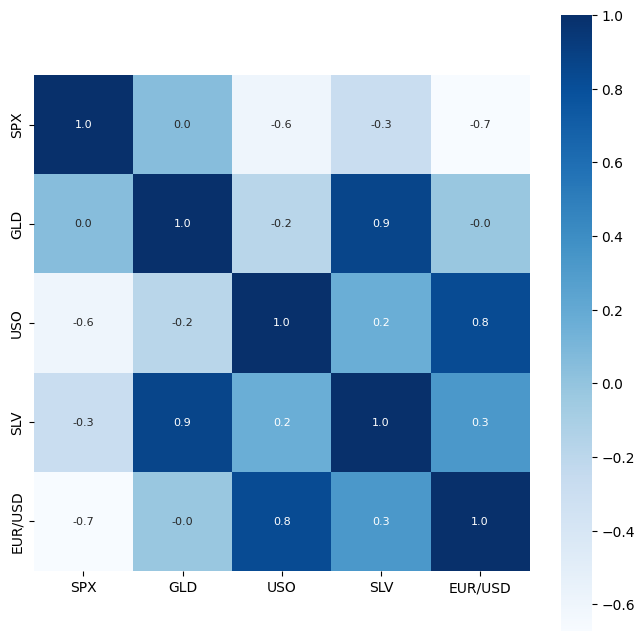

In [40]:
# constructing a heatmap to understand the correlatiom
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

In [41]:
# correlation values of GLD
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


/tmp/ipykernel_1480/563101706.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'],color='green')


<Axes: xlabel='GLD', ylabel='Density'>

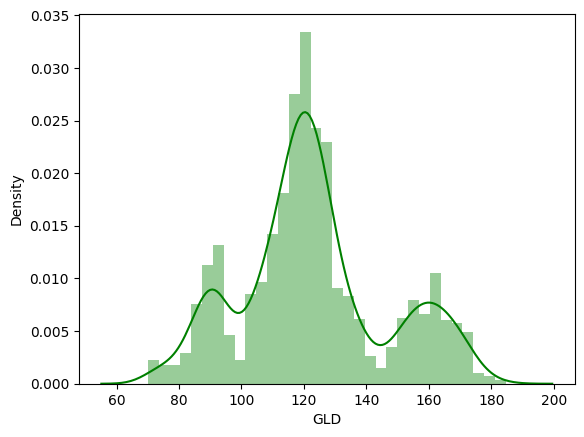

In [42]:
# checking the distribution of the GLD Price
sns.distplot(gold_data['GLD'],color='green')

Splitting the Features and Target

In [43]:
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [44]:
print(X)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]


In [45]:
print(Y)

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Splitting into Training data and Test Data

In [46]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=2)

Model Training:
Random Forest Regressor

In [47]:
regressor = RandomForestRegressor(n_estimators=100)

In [48]:
# training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation

In [49]:
# prediction on Test Data
test_data_prediction = regressor.predict(X_test)

In [50]:
print(test_data_prediction)

[168.49809895  81.7257998  115.91910007 127.65770064 120.69050105
 154.70659758 150.26739818 126.0202     117.45439875 126.02850071
 116.56130106 172.10290134 142.15649922 167.60829831 115.20650013
 117.85260048 138.57500353 169.84090093 159.90410303 158.87830009
 155.0275002  125.39970018 176.42179942 157.46970353 125.2422004
  93.69979986  77.24800023 120.81530005 118.99949898 167.4413997
  88.13650032 125.27390068  91.21810058 117.8895001  121.2272989
 136.51840109 115.48000131 115.48790058 147.19119969 107.07840113
 104.59440246  87.12289776 126.47000059 117.88649998 152.26639897
 119.56729968 108.45669997 108.02699843  93.04670038 127.24839741
  75.17360043 113.75459894 121.32840016 111.10829938 118.93159902
 120.53539942 159.19930048 168.2564012  147.15829695  85.90339837
  94.24490036  86.70819848  90.44120045 119.05500078 126.38850071
 127.42839986 170.09919992 122.41339952 117.48809897  98.50469996
 168.42120211 143.10739846 132.12490245 121.32110218 121.42459947
 119.70920063

In [51]:
# R squared error
error_score = metrics.r2_score(Y_test, test_data_prediction)
print("R squared error : ", error_score)

R squared error :  0.9892565188835851


Compare the Actual Values and Predicted Values in a Plot

In [52]:
Y_test = list(Y_test)

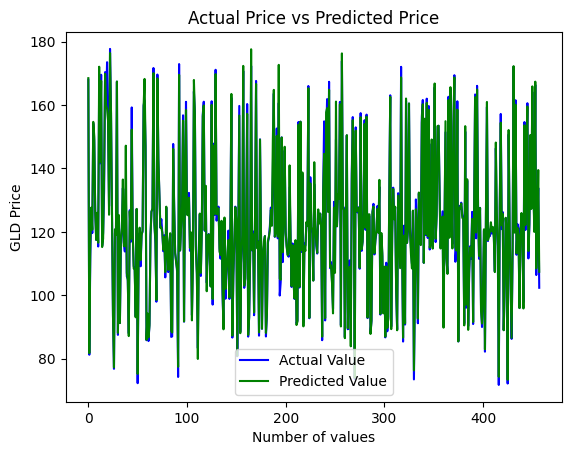

In [53]:
plt.plot(Y_test, color='blue', label = 'Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()

## Saving and Loading the Model

We can save the trained model using `joblib` for later use, and then load it back to demonstrate that it works correctly.

In [54]:
import joblib

# Save the model to a file
filename = 'random_forest_regressor_model.sav'
joblib.dump(regressor, filename)
print(f"Model saved to {filename}")

Model saved to random_forest_regressor_model.sav


In [55]:
# Load the model from the file
loaded_model = joblib.load(filename)
print("Model loaded successfully!")

# Make a prediction with the loaded model to verify
loaded_model_prediction = loaded_model.predict(X_test)

# Compare predictions to ensure the loaded model works
print("First 5 predictions from original model:", test_data_prediction[:5])
print("First 5 predictions from loaded model:", loaded_model_prediction[:5])

# Verify if the predictions are identical
print("Are predictions from original and loaded model identical?", np.array_equal(test_data_prediction, loaded_model_prediction))

Model loaded successfully!
First 5 predictions from original model: [168.49809895  81.7257998  115.91910007 127.65770064 120.69050105]
First 5 predictions from loaded model: [168.49809895  81.7257998  115.91910007 127.65770064 120.69050105]
Are predictions from original and loaded model identical? True


In [56]:
print(loaded_model.feature_names_in_)

['SPX' 'USO' 'SLV' 'EUR/USD']
